In [85]:
!pip install gdown

In [86]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112'
}

In [87]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.cached_download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df


def calculate_grouped_stats_and_ci(df: pd.DataFrame, 
                                   grouping_columns: list, 
                                   value_column: str, 
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for a given value column.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_column (str): The name of the column for which to calculate the mean,
                            count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns.
    """
    
    # Check if value_column is numeric
    if not pd.api.types.is_numeric_dtype(df[value_column]):
        raise TypeError(f"The '{value_column}' must be a numeric column.")

    # Group by the specified columns and aggregate mean, count, and std
    grouped_df = df.groupby(grouping_columns)[value_column].agg(['mean', 'count', 'std']).reset_index()
    grouped_df.rename(columns={'mean': 'Average', 'count': 'Count', 'std': 'Std_Dev'}, inplace=True)

    # Calculate alpha for confidence interval
    alpha = 1 - confidence_level

    # Function to calculate confidence interval for each group
    def calculate_ci_row(row):
        if row['Count'] < 2 or pd.isna(row['Std_Dev']):  # Need at least 2 points and a valid std_dev
            return np.nan, np.nan
        
        # Degrees of freedom for t-distribution
        df_t = row['Count'] - 1
        
        # Calculate standard error of the mean
        sem = row['Std_Dev'] / np.sqrt(row['Count'])
        
        # Calculate confidence interval
        lower, upper = stats.t.interval(confidence_level, df_t, loc=row['Average'], scale=sem)
        return lower, upper

    # Apply the function to each row to get the confidence interval
    grouped_df[['CI_Lower', 'CI_Upper']] = grouped_df.apply(
        lambda row: calculate_ci_row(row), axis=1, result_type='expand'
    )
    
    return grouped_df


In [88]:
scalability_df = get_pandas_from_gid('scalability')
scalability_df

File exists: scalability.csv


,Graph Name,Initial Vertices,Initial Solutions,Timeout (ms),Objective Function,Threads,Repetition,Total Time (ms),Time to Best Solution (ms),Effective Runs,Cost Best Solution,Vertices Best Solution,Edges Best Solution,Best Solution,speedup
0,citeseer,10,100,3000,conductance,32,1,6749.0,3000.0,47,0.999174,2082.0,3627.0,"vsub(nvertices=2082,nedges=3627,vertices={3190...",27.45932731
1,citeseer,10,100,2000,conductance,32,1,4437.0,4000.0,44,0.996935,2037.0,3578.0,"vsub(nvertices=2037,nedges=3578,vertices={3190...",28.20689655
2,citeseer,10,100,1000,conductance,32,1,2532.0,0.0,37,0.989899,47.0,98.0,"vsub(nvertices=47,nedges=98,vertices={511,2935...",25.65995261
3,citeseer,10,100,3000,conductance,32,2,6661.0,6000.0,50,0.997770,2043.0,3580.0,"vsub(nvertices=2043,nedges=3580,vertices={3190...",27.73562528
4,citeseer,10,100,2000,conductance,32,2,4785.0,4000.0,38,0.994951,2018.0,3547.0,"vsub(nvertices=2018,nedges=3547,vertices={3190...",26.37554859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7720,youtube,10,100,2000,triangledensestsubgraph,1,4,206340.0,202000.0,100,241.481928,83.0,1067.0,"vsub(nvertices=83,nedges=1067,vertices={325046...",1
7721,youtube,10,100,1000,triangledensestsubgraph,1,4,104075.0,102000.0,100,240.821429,84.0,1080.0,"vsub(nvertices=84,nedges=1080,vertices={325046...",1
7722,youtube,10,100,2000,triangledensestsubgraph,1,5,207213.0,203000.0,100,241.430233,86.0,1109.0,"vsub(nvertices=86,nedges=1109,vertices={424138...",1
7723,youtube,10,100,3000,triangledensestsubgraph,1,5,312052.0,307000.0,100,238.941177,85.0,1085.0,"vsub(nvertices=85,nedges=1085,vertices={435840...",1


In [89]:
grouping_columns = ["Graph Name", "Objective Function", "Initial Vertices", "Initial Solutions", "Timeout (ms)", "Threads"]
value_column = "Total Time (ms)"
grouped_df = calculate_grouped_stats_and_ci(scalability_df, grouping_columns, value_column)
grouped_df

,Graph Name,Objective Function,Initial Vertices,Initial Solutions,Timeout (ms),Threads,Average,Count,Std_Dev,CI_Lower,CI_Upper
0,citeseer,conductance,10,100,1000,1,64439.6,5,897.445987,63325.273627,65553.926373
1,citeseer,conductance,10,100,1000,2,35567.6,5,300.688876,35194.245448,35940.954552
2,citeseer,conductance,10,100,1000,3,21457.4,5,248.441744,21148.918831,21765.881169
3,citeseer,conductance,10,100,1000,4,16311.0,5,279.002688,15964.572407,16657.427593
4,citeseer,conductance,10,100,1000,5,12790.6,5,232.260199,12502.210873,13078.989127
...,...,...,...,...,...,...,...,...,...,...,...
1540,youtube,triangledensestsubgraph,10,100,3000,28,11067.4,5,844.102067,10019.308852,12115.491148
1541,youtube,triangledensestsubgraph,10,100,3000,29,11647.4,5,492.062293,11036.423966,12258.376034
1542,youtube,triangledensestsubgraph,10,100,3000,30,11431.4,5,551.477379,10746.650392,12116.149608
1543,youtube,triangledensestsubgraph,10,100,3000,31,12115.6,5,1165.980617,10667.843845,13563.356155


In [90]:
import matplotlib.pyplot as plt

def plot_speedup(df: pd.DataFrame, grouping_cols: list):
    """
    Generates a Matplotlib plot showing speedup with respect to 'Average' time
    and 'Threads', grouped by various experimental parameters.
    Includes an 'Ideal Speedup' line for comparison.
    Increased font sizes for better readability.

    Speedup is calculated as (Average time with 1 Thread) / (Average time with N Threads).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'Graph Name', 'Objective Function',
                           'Initial Vertices', 'Initial Solutions', 'Timeout (ms)',
                           'Threads', 'Average', 'Count', 'Std_Dev', 'CI_Lower', 'CI_Upper'.
        grouping_cols (list): A list of column names to group the DataFrame by,
                              defining unique experimental setups.
    """

    # Filter out rows where 'Threads' is not 1 to get the baseline
    df_baseline = df[df['Threads'] == 1].copy()

    # Rename 'Average' in baseline to 'Average_1_Thread' for merging
    df_baseline = df_baseline.rename(columns={'Average': 'Average_1_Thread'})

    # Select only the necessary columns for the baseline and drop duplicates if any
    df_baseline = df_baseline[grouping_cols + ['Average_1_Thread']].drop_duplicates(subset=grouping_cols)

    # Merge the baseline average back into the main DataFrame
    df_merged = pd.merge(df, df_baseline, on=grouping_cols, how='left')

    # Calculate Speedup
    df_merged['Speedup'] = df_merged['Average_1_Thread'] / df_merged['Average']

    # Sort by grouping columns and then by threads for consistent plotting
    df_merged = df_merged.sort_values(by=grouping_cols + ['Threads'])

    # --- Plotting ---
    plt.figure(figsize=(13, 8))
    
    # Iterate through unique experimental setups to plot each as a separate line
    for name, group in df_merged.groupby(grouping_cols):
        # Create a label for the legend
        label = " | ".join([f"{col}: {val}" for col, val in zip(grouping_cols, name)])
        plt.plot(group['Threads'], group['Speedup'], marker='o', label=label)

    # --- Plotting Ideal Speedup ---
    max_threads = df_merged['Threads'].max()
    ideal_threads = np.arange(1, max_threads + 1)
    plt.plot(ideal_threads, ideal_threads, color='black', linestyle='--', label='Ideal Speedup', linewidth=2) # Thicker line for ideal

    # Set font sizes for various plot elements
    #plt.title('Speedup vs. Threads for Different Experimental Setups', fontsize=16)
    plt.xlabel('Number of Threads', fontsize=18)
    plt.ylabel('Speedup', fontsize=18)
    
    # Set tick label font sizes
    plt.xticks(sorted(df_merged['Threads'].unique()), fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust legend font size
    plt.legend(bbox_to_anchor=(0.5, 1), loc='best', borderaxespad=0., fontsize=14, title_fontsize=12)
    
    plt.axhline(y=1.0, color='r', linestyle=':', linewidth=1.5, label='Baseline (1x Speedup)') # Slightly thicker baseline
    plt.tight_layout()
    plt.show()

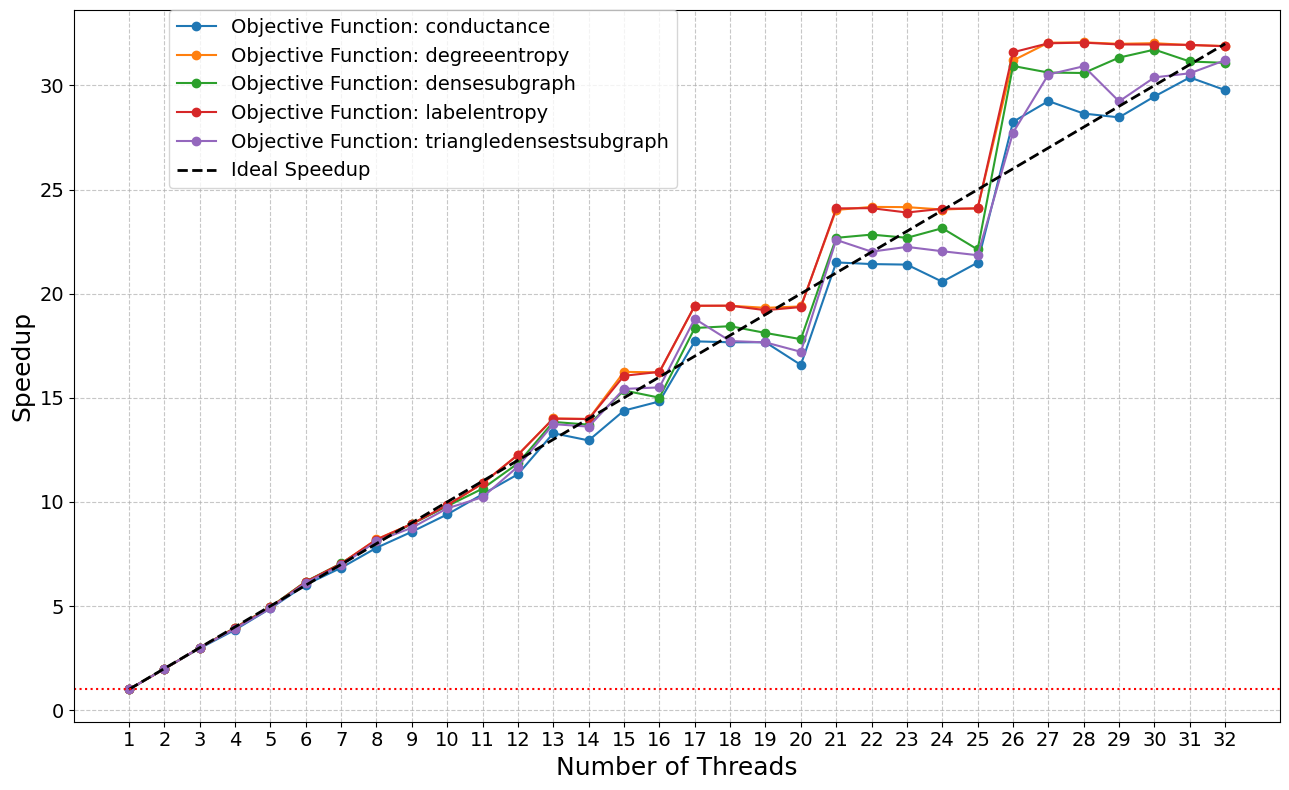

In [91]:
grouping_cols = ["Objective Function"]
df = grouped_df[(grouped_df["Graph Name"] == "patents") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
#df = df[df["Threads"].isin(range(1,33,2))]
plot_speedup(df, grouping_cols)

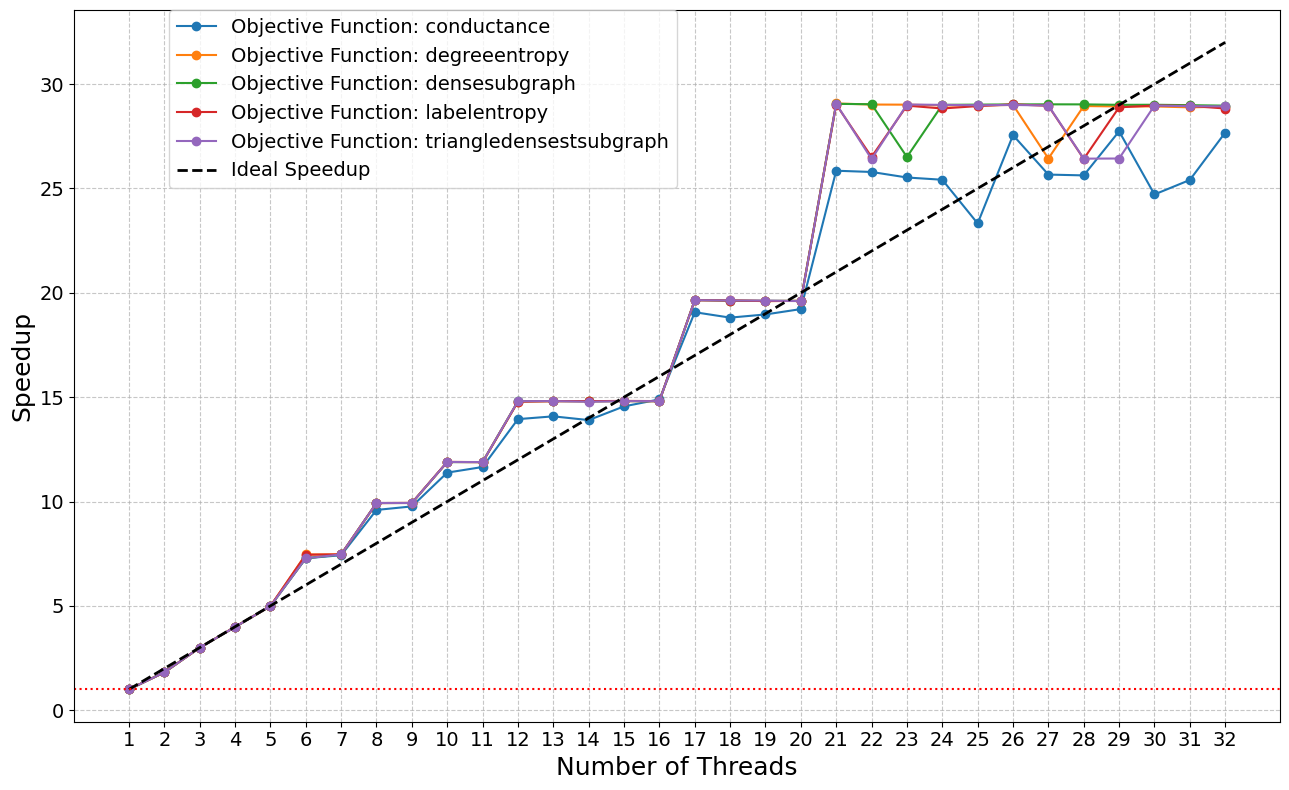

In [92]:
grouping_cols = ["Objective Function"]
df = grouped_df[(grouped_df["Graph Name"] == "citeseer") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols)

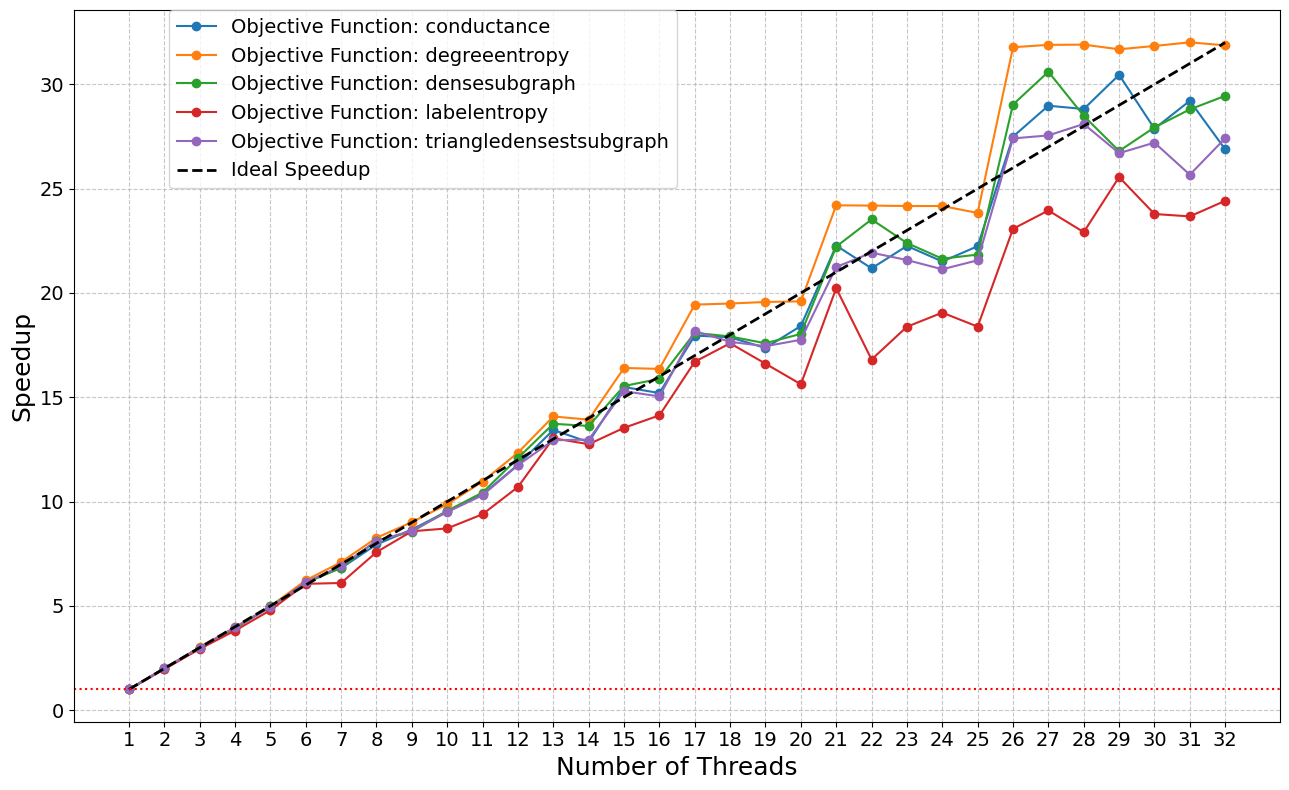

In [93]:
grouping_cols = ["Objective Function"]
df = grouped_df[(grouped_df["Graph Name"] == "youtube") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols)

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_average_with_ci_bars(df: pd.DataFrame, grouping_columns: list):
    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars, grouped by specified columns and with 'Threads' on the x-axis.
    The y-axis is on a logarithmic scale.

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'Threads', 'Average', 'CI_Lower', 'CI_Upper',
                           and the columns specified in grouping_columns.
        grouping_columns (list): A list of column names to group the DataFrame by,
                                 defining unique experimental setups.
    """

    # Filter out any rows where Average, CI_Lower, or CI_Upper are non-positive,
    # as log scale cannot handle zero or negative values.
    df = df[df['Average'] > 0]
    df = df[df['CI_Lower'] > 0]
    df = df[df['CI_Upper'] > 0]

    # Sort for consistent plotting
    df = df.sort_values(by=grouping_columns + ['Threads'])

    plt.figure(figsize=(20, 9)) # Slightly wider figure for bars

    # Get unique thread values for x-axis positioning
    unique_threads = sorted(df['Threads'].unique())
    num_groups = df.groupby(grouping_columns).ngroups # Number of distinct experimental configurations

    # Define bar width and spacing
    bar_width = 0.8 / num_groups
    
    # Generate a distinct color for each group
    colors = plt.cm.get_cmap('tab10', num_groups)
    
    # Keep track of the current group index for x-offset and color
    group_idx = 0
    
    # Iterate through each unique experimental setup
    for name, group in df.groupby(grouping_columns):
        # Create a label for the legend
        label = " | ".join([f"{col}: {val}" for col, val in zip(grouping_columns, name)])
        
        # Calculate the x-position for each bar within a thread count
        # This shifts bars for different groups next to each other
        x_positions = [t + (group_idx - num_groups / 2 + 0.5) * bar_width for t in group['Threads']]
        
        # Calculate the error (difference from mean to CI_Lower/CI_Upper)
        yerr_lower = group['Average'] - group['CI_Lower']
        yerr_upper = group['CI_Upper'] - group['Average']
        
        # Plot the bars
        plt.bar(
            x_positions,
            group['Average'],
            yerr=[yerr_lower, yerr_upper], # Error bars
            width=bar_width,
            capsize=5, # Size of the error bar caps
            label=label,
            color=colors(group_idx), # Assign a unique color
            edgecolor='black', # Add a border to bars
            linewidth=0.8,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5) # Styling for error lines
        )
        group_idx += 1


    plt.title('Average Performance with 95% Confidence Intervals (Log Scale Y-axis)', fontsize=18)
    plt.xlabel('Number of Threads', fontsize=15)
    plt.ylabel('Average Performance (Time/Cost) [Log Scale]', fontsize=15)
    
    # Set y-axis to log scale
    #plt.yscale('log')
    
    # Set x-axis ticks to be centered on the 'Threads' values, not specific bar positions
    plt.xticks(unique_threads, fontsize=13)
    plt.yticks(fontsize=13)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="both", axis='y') # Only Y-axis grid
    plt.grid(False, axis='x') # No X-axis grid for bar plots

    # Place legend outside the plot area for better readability
    plt.legend(title="Experiment Configuration", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=11, title_fontsize=13)
    
    plt.tight_layout(rect=[0, 0, 0.82, 1]) # Adjust layout to make space for the legend
    plt.show()